# Smartwatch price analysis

What actually drives the price of a smartwatch — and how well can the spec sheet alone predict it?

The data is a set of ~380 smartwatch listings from [Kaggle](https://www.kaggle.com/datasets/rkiattisak/smart-watch-prices): brand, model, operating system, display, battery life, water resistance, connectivity and price.

**Plan:**
1. Clean the data — almost every column is stored as text and needs parsing
2. Explore prices, brands and specs
3. Train and compare regression models (a naive baseline, linear models, a decision tree and a random forest)
4. Look at which features matter and how much of the price they explain

## 1. Load and first look

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

RANDOM_STATE = 42

In [2]:
df = pd.read_csv('Smart watch prices.csv')
print(df.shape)
df.head()

(379, 13)


,Brand,Model,Operating System,Connectivity,Display Type,Display Size (inches),Resolution,Water Resistance (meters),Battery Life (days),Heart Rate Monitor,GPS,NFC,Price (USD)
0,Apple,Watch Series 7,watchOS,"Bluetooth, Wi-Fi, Cellular",Retina,1.90,396 x 484,50,18,Yes,Yes,Yes,$399
1,Samsung,Galaxy Watch 4,Wear OS,"Bluetooth, Wi-Fi, Cellular",AMOLED,1.40,450 x 450,50,40,Yes,Yes,Yes,$249
2,Garmin,Venu 2,Garmin OS,"Bluetooth, Wi-Fi",AMOLED,1.30,416 x 416,50,11,Yes,Yes,No,$399
3,Fitbit,Versa 3,Fitbit OS,"Bluetooth, Wi-Fi",AMOLED,1.58,336 x 336,50,6,Yes,Yes,Yes,$229
4,Fossil,Gen 6,Wear OS,"Bluetooth, Wi-Fi",AMOLED,1.28,416 x 416,30,24,Yes,Yes,Yes,$299


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 379 entries, 0 to 378
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Brand                      378 non-null    object 
 1   Model                      378 non-null    object 
 2   Operating System           376 non-null    object 
 3   Connectivity               378 non-null    object 
 4   Display Type               377 non-null    object 
 5   Display Size (inches)      376 non-null    float64
 6   Resolution                 375 non-null    object 
 7   Water Resistance (meters)  378 non-null    object 
 8   Battery Life (days)        378 non-null    object 
 9   Heart Rate Monitor         378 non-null    object 
 10  GPS                        378 non-null    object 
 11  NFC                        378 non-null    object 
 12  Price (USD)                378 non-null    object 
dtypes: float64(1), object(12)
memory usage: 38.6+ KB


Only `Display Size (inches)` came in as a number. Everything else is text, including columns that are clearly numeric in nature:

- `Price (USD)` is stored like `"$399 "` — with a dollar sign and a trailing space
- `Battery Life (days)` mixes plain numbers with `"48 hours"` and `"Unlimited"`
- `Water Resistance (meters)` has `"Not specified"` mixed in
- `Resolution` is a single string like `"396 x 484"`
- `Connectivity` packs several features into one string like `"Bluetooth, Wi-Fi, Cellular"`

So before any analysis, each of these needs to be converted into a proper numeric or boolean column.

## 2. Cleaning

### 2.1 Parsing the text columns

In [4]:
# Price: "$399 " -> 399.0
df['Price (USD)'] = pd.to_numeric(
    df['Price (USD)'].astype(str).str.replace('$', '').str.replace(',', '').str.strip(),
    errors='coerce'
)

df['Price (USD)'].describe().round(1)

count     378.0
mean      312.9
std       202.4
min        49.0
25%       199.0
50%       279.0
75%       329.0
max      1800.0
Name: Price (USD), dtype: float64

In [5]:
# Battery life has mixed formats
df['Battery Life (days)'].unique()

array(['18', '40', '11', '6', '24', '14', '2', '4', '12', '30', '3', '45',
       '5', '10', '48', '7', '16', '9', '25', '72', '60', '56', nan, '70',
       '1', '48 hours', '15', 'Unlimited', '1.5', '20', '8'], dtype=object)

In [6]:
def battery_to_days(value):
    """Convert battery life to a number of days. 'Unlimited' (solar watches) -> NaN."""
    if pd.isnull(value):
        return np.nan
    value = str(value).strip().lower()
    if value == 'unlimited':
        return np.nan
    if 'hour' in value:
        return float(value.split()[0]) / 24
    try:
        return float(value.split()[0])
    except ValueError:
        return np.nan

df['Battery Life (days)'] = df['Battery Life (days)'].apply(battery_to_days)

# Water resistance: "Not specified" -> NaN, the rest are plain numbers
df['Water Resistance (meters)'] = pd.to_numeric(df['Water Resistance (meters)'], errors='coerce')

In [7]:
# Resolution "396 x 484" -> one number: total pixels (in thousands)
res = df['Resolution'].str.extract(r'(\d+)\s*x\s*(\d+)').astype(float)
df['Resolution (kpx)'] = res[0] * res[1] / 1000

# Connectivity: split the combined string into separate flags.
# Bluetooth is present in every row, so only Wi-Fi and Cellular carry information.
df['Has Wi-Fi'] = df['Connectivity'].str.contains('Wi-Fi', na=False).astype(int)
df['Has Cellular'] = df['Connectivity'].str.contains('Cellular', na=False).astype(int)

# Yes/No columns -> 1/0
for col in ['GPS', 'NFC']:
    df[col] = (df[col] == 'Yes').astype(int)

df[['Price (USD)', 'Battery Life (days)', 'Water Resistance (meters)',
    'Resolution (kpx)', 'Has Wi-Fi', 'Has Cellular', 'GPS', 'NFC']].head()

,Price (USD),Battery Life (days),Water Resistance (meters),Resolution (kpx),Has Wi-Fi,Has Cellular,GPS,NFC
0,399.0,18.0,50.0,191.664,1,1,1,1
1,249.0,40.0,50.0,202.500,1,1,1,1
2,399.0,11.0,50.0,173.056,1,0,1,0
3,229.0,6.0,50.0,112.896,1,0,1,1
4,299.0,24.0,30.0,173.056,1,0,1,1


### 2.2 Duplicates

This step turned out to matter much more than I expected.

In [8]:
print('Exact duplicate rows:', df.duplicated().sum())

# Keep a copy with duplicates for an experiment in section 5,
# then drop them for the rest of the analysis
df_with_dups = df.copy()
df = df.drop_duplicates().reset_index(drop=True)
print('Rows after deduplication:', len(df))

Exact duplicate rows: 80
Rows after deduplication: 299


80 out of 379 rows (21%) were exact copies of another row. This is not just noise: with a random train/test split, the same watch ends up in both sets, and a flexible model gets rewarded for *memorizing* it rather than learning anything general. An earlier version of this notebook skipped this check and reported test R² of ~0.8 for tree models — section 5 shows how much of that was an illusion.

### 2.3 Missing values

In [9]:
df.isnull().sum()[lambda s: s > 0]

Brand                        1
Model                        1
Operating System             3
Connectivity                 1
Display Type                 2
Display Size (inches)        3
Resolution                   4
Water Resistance (meters)    2
Battery Life (days)          4
Heart Rate Monitor           1
Price (USD)                  1
Resolution (kpx)             4
dtype: int64

In [10]:
# A row without a price (the target) or a brand is not usable
df = df.dropna(subset=['Price (USD)', 'Brand']).reset_index(drop=True)

# The remaining gaps are a handful of values per column -> fill numeric ones
# with the median, categorical ones with 'Unknown'
for col in ['Battery Life (days)', 'Water Resistance (meters)',
            'Resolution (kpx)', 'Display Size (inches)']:
    df[col] = df[col].fillna(df[col].median())

for col in ['Operating System', 'Display Type']:
    df[col] = df[col].fillna('Unknown')

print('Rows in the cleaned dataset:', len(df))

Rows in the cleaned dataset: 298


### 2.4 Columns that cannot help the models

Two columns look informative but are not:

In [11]:
print('Unique values in Model:', df['Model'].nunique(), 'out of', len(df), 'rows')
print('Heart Rate Monitor:', df_with_dups['Heart Rate Monitor'].value_counts(dropna=False).to_dict())

Unique values in Model: 137 out of 298 rows
Heart Rate Monitor: {'Yes': 378, nan: 1}


- `Model` is almost an ID — 137 unique names across ~300 watches. One-hot encoding it would give a model a way to look up a specific watch instead of learning from its specs, so I keep it for labeling only, not as a feature.
- `Heart Rate Monitor` is `"Yes"` for every single watch in the dataset. A constant column carries no signal.

## 3. Exploring the data

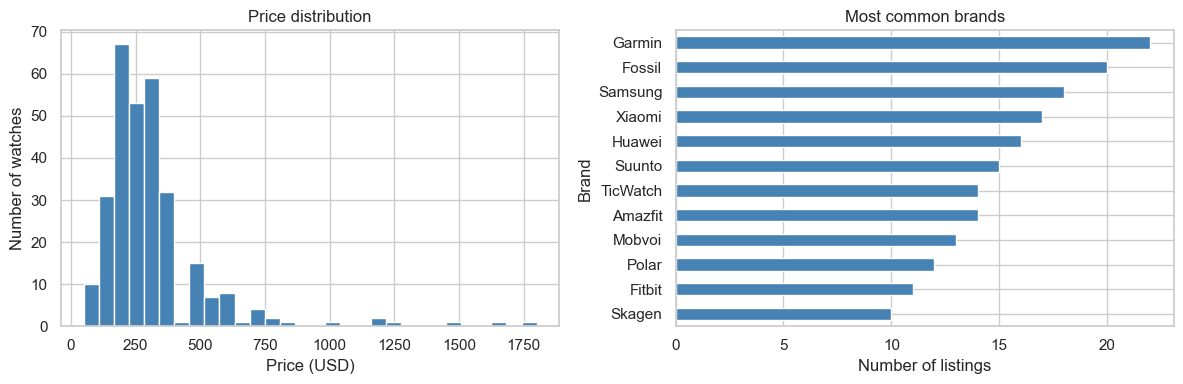

count     298.0
mean      315.0
std       218.0
min        49.0
25%       199.0
50%       279.0
75%       349.0
max      1800.0
Name: Price (USD), dtype: float64

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['Price (USD)'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Price (USD)')
axes[0].set_ylabel('Number of watches')
axes[0].set_title('Price distribution')

df['Brand'].value_counts().head(12).plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].invert_yaxis()
axes[1].set_xlabel('Number of listings')
axes[1].set_title('Most common brands')
plt.tight_layout()
plt.show()

df['Price (USD)'].describe().round(0)

Prices are right-skewed: half of the watches cost under \$279, but the tail stretches to \$1,800 (premium Garmin and TAG Heuer models). The brand mix is dominated by sports/fitness brands — Garmin, Fitbit, Mobvoi, Fossil, Amazfit.

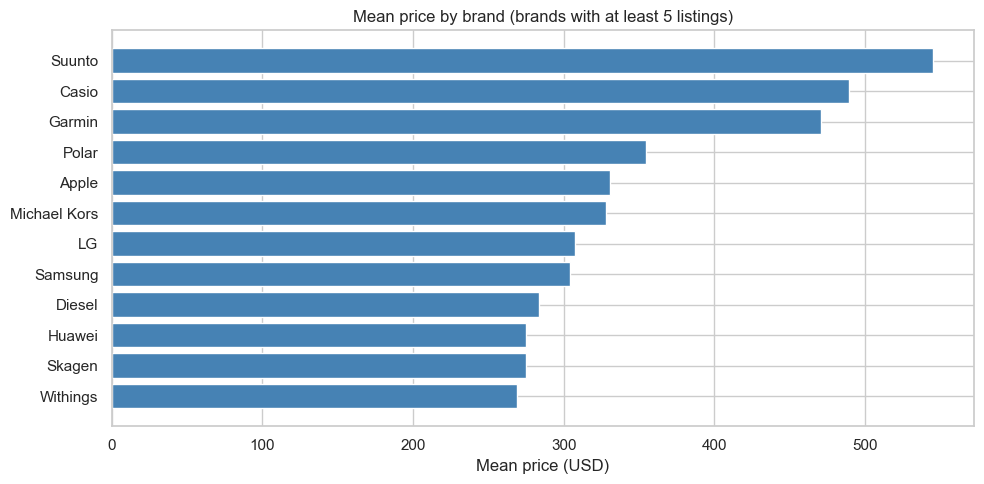

In [13]:
brand_price = (df.groupby('Brand')['Price (USD)']
                 .agg(['mean', 'count'])
                 .query('count >= 5')
                 .sort_values('mean', ascending=False))

plt.figure(figsize=(10, 5))
plt.barh(brand_price.index[:12], brand_price['mean'][:12], color='steelblue')
plt.gca().invert_yaxis()
plt.xlabel('Mean price (USD)')
plt.title('Mean price by brand (brands with at least 5 listings)')
plt.tight_layout()
plt.show()

There is a clear brand premium: Suunto, Casio and Garmin average around \$450–550, while brands like Amazfit, Xiaomi or Realme sit well under \$200 with broadly similar spec sheets. This already suggests brand will do part of the work that specs alone cannot.

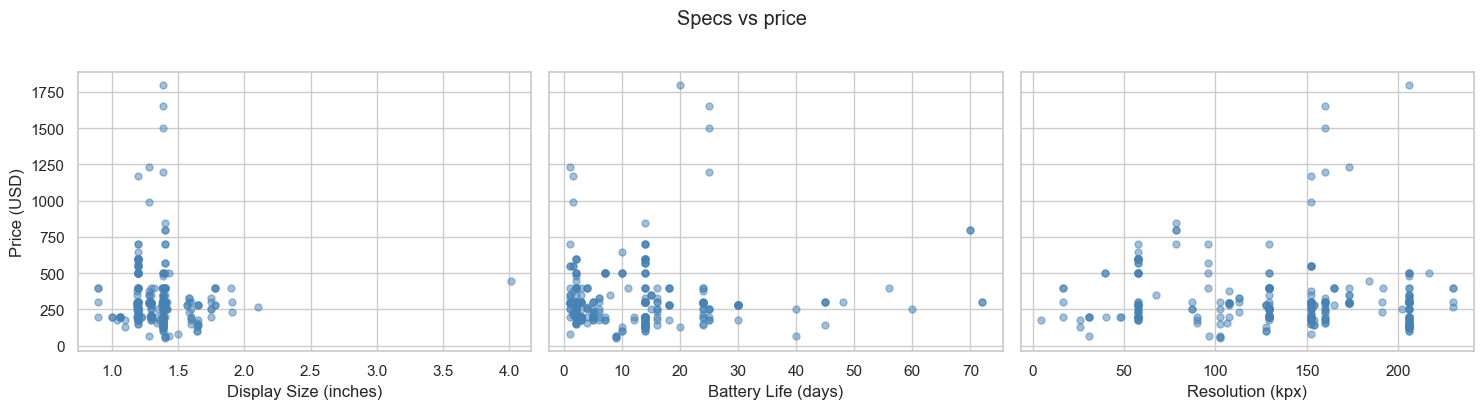

In [14]:
# How do individual specs relate to price?
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, col in zip(axes, ['Display Size (inches)', 'Battery Life (days)', 'Resolution (kpx)']):
    ax.scatter(df[col], df['Price (USD)'], alpha=0.5, s=25, color='steelblue')
    ax.set_xlabel(col)
axes[0].set_ylabel('Price (USD)')
fig.suptitle('Specs vs price', y=1.02)
plt.tight_layout()
plt.show()

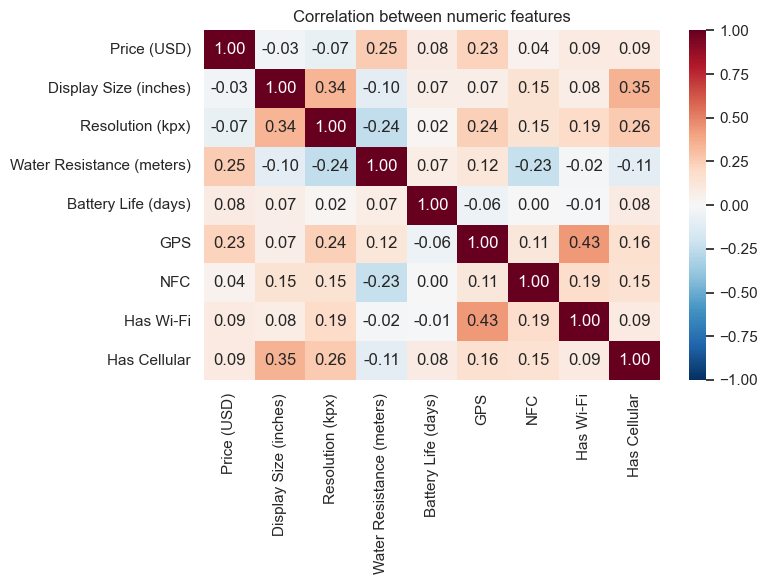

In [15]:
numeric_cols = ['Price (USD)', 'Display Size (inches)', 'Resolution (kpx)',
                'Water Resistance (meters)', 'Battery Life (days)',
                'GPS', 'NFC', 'Has Wi-Fi', 'Has Cellular']

plt.figure(figsize=(8, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1)
plt.title('Correlation between numeric features')
plt.tight_layout()
plt.show()

The scatter plots and the heatmap tell the same, slightly uncomfortable story: **no single spec correlates strongly with price**. The best of them, water resistance and GPS, reach only ~0.25. The 4-inch outlier on the display-size plot is real, by the way — the Nubia Alpha, a wearable phone with a flexible band-length screen.

This sets expectations for the modeling part: with ~300 watches and such weak individual relationships, no model is going to explain most of the price. Whatever signal exists is spread across brand and combinations of specs.

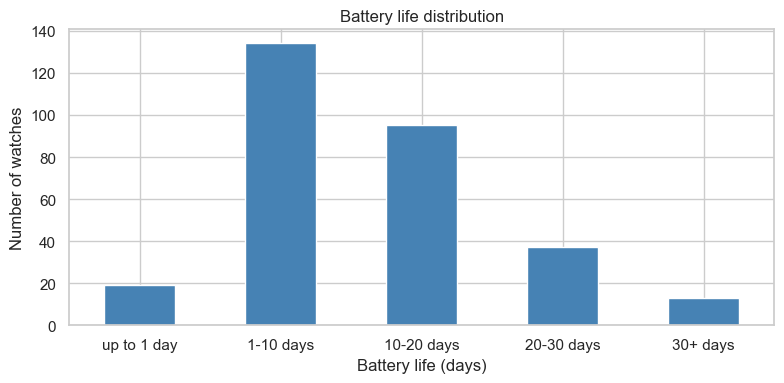

In [16]:
# Bucketed view of battery life: parse first, bucket only for display
battery_bins = pd.cut(df['Battery Life (days)'],
                      bins=[0, 1, 10, 20, 30, np.inf],
                      labels=['up to 1 day', '1-10 days', '10-20 days', '20-30 days', '30+ days'])

ax = battery_bins.value_counts().sort_index().plot(kind='bar', figsize=(8, 4),
                                                   color='steelblue', rot=0)
ax.set_xlabel('Battery life (days)')
ax.set_ylabel('Number of watches')
ax.set_title('Battery life distribution')
plt.tight_layout()
plt.show()

Most watches advertise 1–10 days of battery; the 20+ day group is mostly fitness bands and MIP-display sports watches.

*(In an earlier version I bucketed the raw strings like `"48 hours"` directly into categories and fed those buckets to the models as one-hot columns. Parsing to numbers first is strictly better: the plots above stay possible, and the models in section 5 get the actual values instead of coarse, unordered buckets.)*

## 4. Features for modeling

**Used as features:** brand, operating system, display type (one-hot encoded), display size, resolution, water resistance, battery life, GPS, NFC, Wi-Fi, Cellular.

**Left out:** `Model` (ID-like, see 2.4), `Heart Rate Monitor` (constant), and the raw text columns replaced by their parsed versions.

Two details that fix the problems an earlier version of this notebook had:

- **Rare categories are grouped into `"Other"`.** 42 brands / 35 operating systems for ~300 rows would mean dozens of dummy columns seen only a few times each.
- **One-hot encoding uses `drop_first=True`.** Without it, the dummies of each categorical column sum to 1 — an exact copy of the intercept — and the linear regression matrix becomes singular (the "dummy variable trap"). My first attempt encoded *everything* including `Model`, ended up with 248 features for ~260 training rows, and produced coefficients in the trillions and a test R² of −5×10²¹. Nothing was "wrong" with the solver — the problem was that infinitely many coefficient combinations fit such a matrix equally well, so the ones it picked were meaningless.

In [17]:
# Group categories with fewer than 5 watches into 'Other'
for col in ['Brand', 'Operating System', 'Display Type']:
    counts = df[col].value_counts()
    rare = counts[counts < 5].index
    df[col] = df[col].where(~df[col].isin(rare), 'Other')
    print(f'{col}: {df[col].nunique()} categories after grouping')

Brand: 23 categories after grouping
Operating System: 15 categories after grouping
Display Type: 11 categories after grouping


In [18]:
features = ['Brand', 'Operating System', 'Display Type',
            'Display Size (inches)', 'Resolution (kpx)', 'Water Resistance (meters)',
            'Battery Life (days)', 'GPS', 'NFC', 'Has Wi-Fi', 'Has Cellular']

X = pd.get_dummies(df[features],
                   columns=['Brand', 'Operating System', 'Display Type'],
                   drop_first=True)
y = df['Price (USD)']

print('Feature matrix:', X.shape)

Feature matrix: (298, 54)


In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE
)
print(f'Train: {len(X_train)} watches, test: {len(X_test)} watches')

Train: 208 watches, test: 90 watches


## 5. Models

### 5.1 Naive baseline

Before any real model: how wrong are we if we just predict the mean price for every watch? Every model below has to beat this to justify its existence.

In [20]:
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, r2_score

baseline = DummyRegressor(strategy='mean').fit(X_train, y_train)
baseline_mae = mean_absolute_error(y_test, baseline.predict(X_test))
print(f'Baseline (predict the mean): MAE = ${baseline_mae:.0f}')

Baseline (predict the mean): MAE = $121


### 5.2 Linear regression

In [21]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression().fit(X_train, y_train)

print(f'Train R²: {lin_reg.score(X_train, y_train):.3f}')
print(f'Test  R²: {lin_reg.score(X_test, y_test):.3f}')
print(f'Test MAE: ${mean_absolute_error(y_test, lin_reg.predict(X_test)):.0f}')

Train R²: 0.536
Test  R²: 0.403
Test MAE: $98


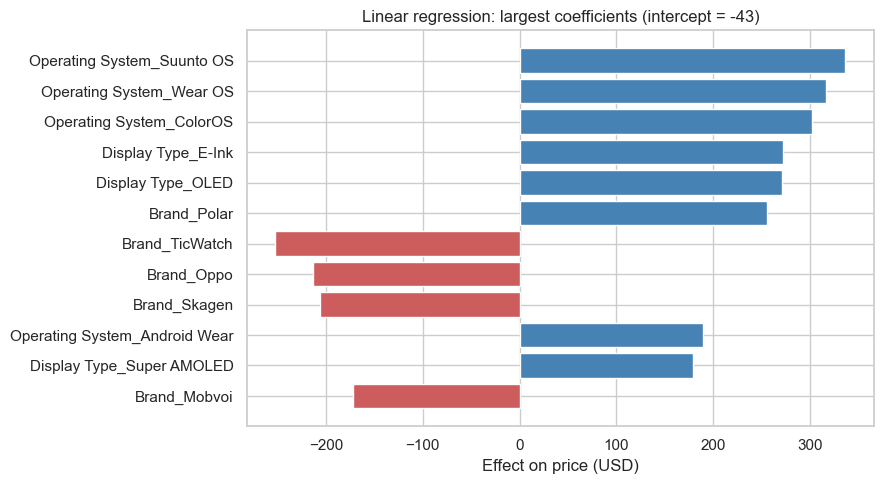

In [22]:
coefs = pd.Series(lin_reg.coef_, index=X.columns)
top_coefs = coefs.reindex(coefs.abs().sort_values(ascending=False).index)[:12]

plt.figure(figsize=(9, 5))
colors = ['indianred' if c < 0 else 'steelblue' for c in top_coefs[::-1]]
plt.barh(top_coefs.index[::-1], top_coefs[::-1], color=colors)
plt.xlabel('Effect on price (USD)')
plt.title(f'Linear regression: largest coefficients (intercept = {lin_reg.intercept_:.0f})')
plt.tight_layout()
plt.show()

With the fixed feature matrix the coefficients are finally on a sane scale — hundreds of dollars, not trillions — and they are dominated by brand and operating-system dummies, which matches the brand-premium chart from section 3.

A caveat at this sample size: with ~50 features for ~200 training rows, ordinary least squares can still fit noise. A standard remedy is **ridge regression** — the same linear model with a penalty on large coefficients:

In [23]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=10).fit(X_train, y_train)
print(f'Test R²: {ridge.score(X_test, y_test):.3f}')
print(f'Test MAE: ${mean_absolute_error(y_test, ridge.predict(X_test)):.0f}')

Test R²: 0.399
Test MAE: $90


On the single train/test split ridge looks almost identical to plain linear regression — the cross-validation table in 5.5 will show the real difference between them.

### 5.3 Decision tree

In [24]:
from sklearn.tree import DecisionTreeRegressor

tree_default = DecisionTreeRegressor(random_state=RANDOM_STATE).fit(X_train, y_train)
print(f'Train R²: {tree_default.score(X_train, y_train):.3f}')
print(f'Test  R²: {tree_default.score(X_test, y_test):.3f}')

Train R²: 0.993
Test  R²: 0.152


A textbook case of overfitting: the unconstrained tree memorizes the training set almost perfectly (R² ≈ 0.99) and falls apart on the test set. Limiting the depth and the minimum leaf size should help — I pick them with a small grid search, cross-validated on the training set only:

In [25]:
from sklearn.model_selection import GridSearchCV, KFold

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid = GridSearchCV(
    DecisionTreeRegressor(random_state=RANDOM_STATE),
    param_grid={'max_depth': range(2, 11), 'min_samples_leaf': [2, 5, 10, 20]},
    cv=cv, scoring='r2'
).fit(X_train, y_train)

tree_tuned = grid.best_estimator_
print('Best parameters:', grid.best_params_)
print(f'Test R²: {tree_tuned.score(X_test, y_test):.3f}')
print(f'Test MAE: ${mean_absolute_error(y_test, tree_tuned.predict(X_test)):.0f}')

Best parameters: {'max_depth': 9, 'min_samples_leaf': 10}
Test R²: 0.146
Test MAE: $101


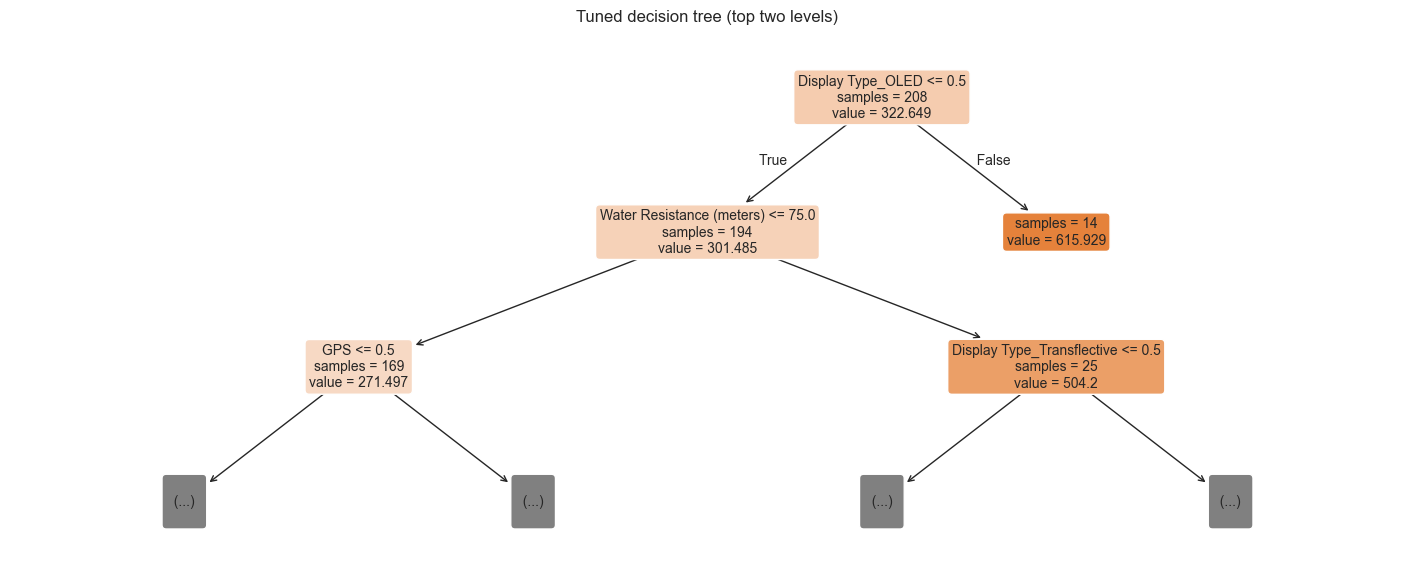

In [26]:
from sklearn.tree import plot_tree

plt.figure(figsize=(18, 7))
plot_tree(tree_tuned, feature_names=X.columns, filled=True, max_depth=2,
          fontsize=10, rounded=True, impurity=False)
plt.title('Tuned decision tree (top two levels)')
plt.show()

Tuning fixes the memorization, but the test score barely moves — on ~200 training rows a single tree is a weak model no matter how it is pruned. Its structure is at least interpretable now: the root split separates OLED displays from the rest, and the next level splits on water resistance — the same features the EDA pointed at.

The standard way to get more out of trees is to average a few hundred of them trained on random subsets of rows and features — a random forest.

### 5.4 Random forest

In [27]:
from sklearn.ensemble import RandomForestRegressor

forest = RandomForestRegressor(n_estimators=400, min_samples_leaf=2,
                               random_state=RANDOM_STATE).fit(X_train, y_train)

print(f'Train R²: {forest.score(X_train, y_train):.3f}')
print(f'Test  R²: {forest.score(X_test, y_test):.3f}')
print(f'Test MAE: ${mean_absolute_error(y_test, forest.predict(X_test)):.0f}')

Train R²: 0.733
Test  R²: 0.424
Test MAE: $76


### 5.5 Model comparison

A single 70/30 split of ~300 rows leaves only ~90 watches in the test set, so the scores above carry a lot of luck. To compare the models more honestly I also run 5-fold cross-validation on the full dataset:

In [28]:
from sklearn.model_selection import cross_val_score

models = {
    'Baseline (mean)': DummyRegressor(strategy='mean'),
    'Linear regression': LinearRegression(),
    'Ridge (alpha=10)': Ridge(alpha=10),
    'Decision tree (tuned)': DecisionTreeRegressor(random_state=RANDOM_STATE,
                                                   **grid.best_params_),
    'Random forest': RandomForestRegressor(n_estimators=400, min_samples_leaf=2,
                                           random_state=RANDOM_STATE),
}

rows = []
for name, model in models.items():
    r2_cv = cross_val_score(model, X, y, cv=cv, scoring='r2')
    mae_cv = -cross_val_score(model, X, y, cv=cv, scoring='neg_mean_absolute_error')
    rows.append({'Model': name,
                 'CV R² (mean ± std)': f'{r2_cv.mean():.2f} ± {r2_cv.std():.2f}',
                 'CV MAE (USD)': f'{mae_cv.mean():.0f}'})

pd.DataFrame(rows).set_index('Model')

,CV R² (mean ± std),CV MAE (USD)
Model,,
Baseline (mean),-0.02 ± 0.02,134
Linear regression,0.04 ± 0.57,115
Ridge (alpha=10),0.30 ± 0.18,104
Decision tree (tuned),0.12 ± 0.15,111
Random forest,0.20 ± 0.26,92


Takeaways from the table:

- **The random forest is the best model**, but even it explains well under half of the price variance.
- **Ridge beats plain linear regression by a lot in cross-validation** even though they looked identical on the single split — without the penalty, OLS coefficients swing wildly between folds. That instability is the mild version of the same disease that produced the trillion-scale coefficients in the first version of this notebook.
- The large standard deviations are the honest cost of a ~300-row dataset.

### 5.6 How much were the duplicates worth?

Back in section 2, 80 duplicate rows were dropped before splitting. Here is what happens if you don't — same features, same model, same kind of split, on the data *with* duplicates:

In [29]:
# Same cleaning steps, but on the version of the data where duplicates were kept
dup = df_with_dups.dropna(subset=['Price (USD)', 'Brand']).copy()
for col in ['Battery Life (days)', 'Water Resistance (meters)',
            'Resolution (kpx)', 'Display Size (inches)']:
    dup[col] = dup[col].fillna(dup[col].median())
for col in ['Operating System', 'Display Type']:
    dup[col] = dup[col].fillna('Unknown')

X_dup = pd.get_dummies(dup[features],
                       columns=['Brand', 'Operating System', 'Display Type'],
                       drop_first=True)
y_dup = dup['Price (USD)']

Xd_train, Xd_test, yd_train, yd_test = train_test_split(
    X_dup, y_dup, test_size=0.3, random_state=RANDOM_STATE)

forest_dup = RandomForestRegressor(n_estimators=400, min_samples_leaf=2,
                                   random_state=RANDOM_STATE).fit(Xd_train, yd_train)

mae_dup = mean_absolute_error(yd_test, forest_dup.predict(Xd_test))
mae_clean = mean_absolute_error(y_test, forest.predict(X_test))
print(f'Random forest MAE with duplicates kept : ${mae_dup:.0f}')
print(f'Random forest MAE, deduplicated data   : ${mae_clean:.0f}')

Random forest MAE with duplicates kept : $41
Random forest MAE, deduplicated data   : $76


Keeping the duplicates makes the model look almost twice as accurate — but only because many "test" watches were also sitting in the training set, sometimes several times. The model isn't predicting their price, it's remembering it. The earlier version of this analysis combined this leak with one-hot-encoded model names (a literal lookup key) and reported R² ≈ 0.8; the realistic numbers are what the table in 5.5 shows.

### 5.7 What drives the price?

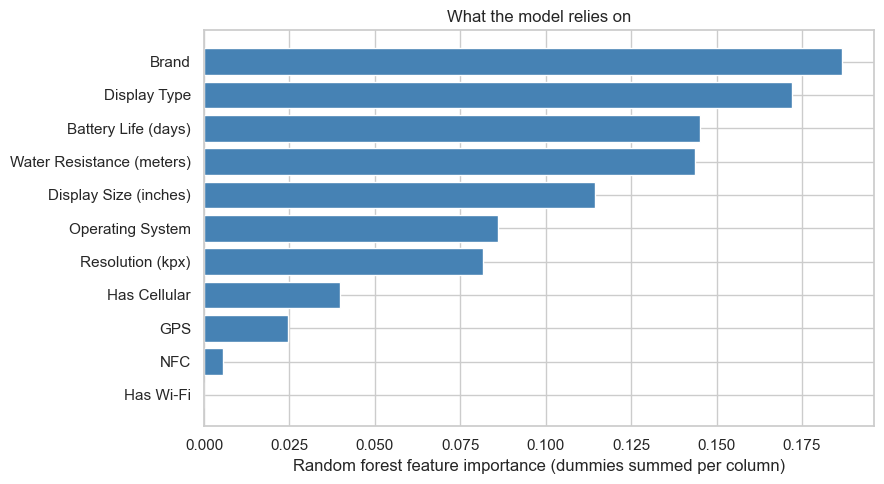

In [30]:
importances = pd.Series(forest.feature_importances_, index=X.columns)

# Sum the one-hot dummies back into their original columns for readability
grouped = importances.groupby(
    importances.index.str.replace(r'^(Brand|Operating System|Display Type)_.*', r'\1', regex=True)
).sum().sort_values()

plt.figure(figsize=(9, 5))
plt.barh(grouped.index, grouped, color='steelblue')
plt.xlabel('Random forest feature importance (dummies summed per column)')
plt.title('What the model relies on')
plt.tight_layout()
plt.show()

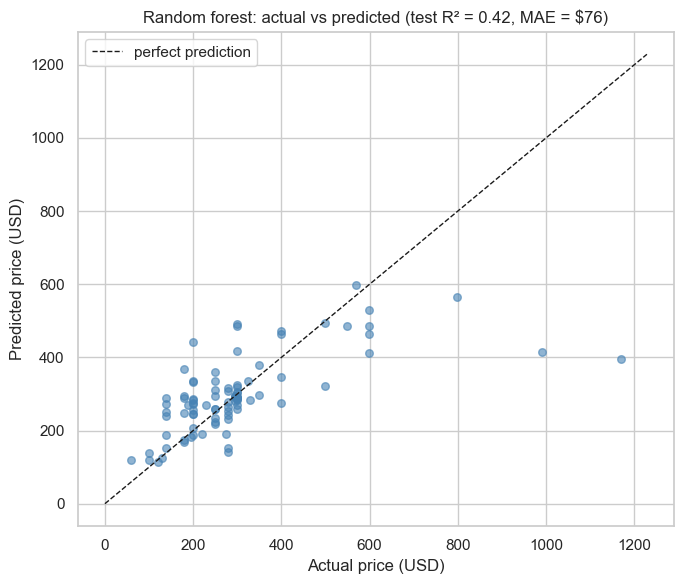

In [31]:
y_pred = forest.predict(X_test)

plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred, alpha=0.6, s=30, color='steelblue')
lims = [0, max(y_test.max(), y_pred.max()) * 1.05]
plt.plot(lims, lims, 'k--', lw=1, label='perfect prediction')
plt.xlabel('Actual price (USD)')
plt.ylabel('Predicted price (USD)')
plt.title(f'Random forest: actual vs predicted '
          f'(test R² = {r2_score(y_test, y_pred):.2f}, MAE = ${mean_absolute_error(y_test, y_pred):.0f})')
plt.legend()
plt.tight_layout()
plt.show()

The model is reasonable in the crowded \$100–400 range and systematically under-predicts the expensive watches — exactly the watches whose price is set by brand positioning and materials (titanium, sapphire glass) that aren't in this dataset at all.

## 6. Conclusions

**Modeling results.** Predicting the mean price for every watch is off by ~\$120 on average. The best model, a random forest, cuts that error to \$76 on the test set (\$92 in cross-validation) and explains roughly 20–40% of the price variance, depending on how it is evaluated. Brand and display type carry the most signal, followed by battery life and water resistance; resolution and connectivity add almost nothing.

**The two most valuable lessons came from things that initially went wrong:**

1. **Exploding regression coefficients.** One-hot encoding every column — including 137 unique model names — without `drop_first` produced a rank-deficient matrix, coefficients in the trillions, and a test R² of −5×10²¹. The fix was less encoding, not more: drop ID-like columns, group rare categories, keep numeric columns numeric.
2. **Data leakage through duplicates.** 21% of the rows were exact copies. With them left in, the random forest looked almost twice as accurate as it really is (MAE \$41 vs \$76), and earlier versions reported R² ≈ 0.8 that did not survive deduplication.

**Limitations.** ~300 watches after cleaning is a small dataset, and the listing prices have no timestamp or region attached. Spec sheets simply don't contain a large part of what determines a smartwatch's price: brand positioning, materials, and release year.

**Possible next steps:** model log-price to handle the skewed target, try gradient boosting, and collect a larger dataset with release dates — or reframe the task as classifying watches into price segments (budget / mid-range / premium), which this amount of data could support better than exact price regression.